# 🏥 Medical Cost Prediction — Analysis

**Dataset:** [Kaggle Insurance Dataset](https://www.kaggle.com/mirichoi0218/insurance)  
**Goal:** Predict individual medical insurance charges using patient demographic and health information.

## Key Findings
| Area | What Changed |
|------|--------------|
| Feature Engineering | 6 new derived features including interaction terms |
| Feature Importance | RF importance + Permutation Importance + Correlation |
| Models | Added Ridge, Lasso, Gradient Boosting, XGBoost |
| Evaluation | Added cross-validation, unified comparison table |
| Code | Fixed all deprecated API calls (`distplot` → `kdeplot`) |

---

## Dataset Variables
| Variable | Type | Description |
|----------|------|-------------|
| `age` | int | Age of primary beneficiary |
| `sex` | str | Gender (male / female) |
| `bmi` | float | Body Mass Index |
| `children` | int | Number of children covered |
| `smoker` | str | Smoking status (yes / no) |
| `region` | str | US residential region |
| `charges` | float | **Target** — Individual medical costs |

## MD ANWARUL KARIM<u> 
*Masters In Data Science*

## 1. Setup & Imports

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

print('All libraries loaded ✅')

All libraries loaded ✅


## 2. Load & Inspect Data

In [3]:
df = pd.read_csv('insurance.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
age,1338.000000,39.207025,14.049960,18.000000,27.000000,39.000000,51.000000,64.000000
bmi,1338.000000,30.663397,6.098187,15.960000,26.296250,30.400000,34.693750,53.130000
children,1338.000000,1.094918,1.205493,0.000000,0.000000,1.000000,2.000000,5.000000
charges,1338.000000,13270.422265,12110.011237,1121.873900,4740.287150,9382.033000,16639.912515,63770.428010


In [6]:
# Missing values check
missing = df.isnull().sum()
print('Missing values:\n', missing[missing > 0] if missing.sum() > 0 else 'None — dataset is clean ✅')

Missing values:
 None — dataset is clean ✅


In [7]:
# Categorical distributions
for col in ['sex', 'smoker', 'region']:
    print(f'\n{col.upper()}:')
    print(df[col].value_counts())


SEX:
sex
male      676
female    662
Name: count, dtype: int64

SMOKER:
smoker
no     1064
yes     274
Name: count, dtype: int64

REGION:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

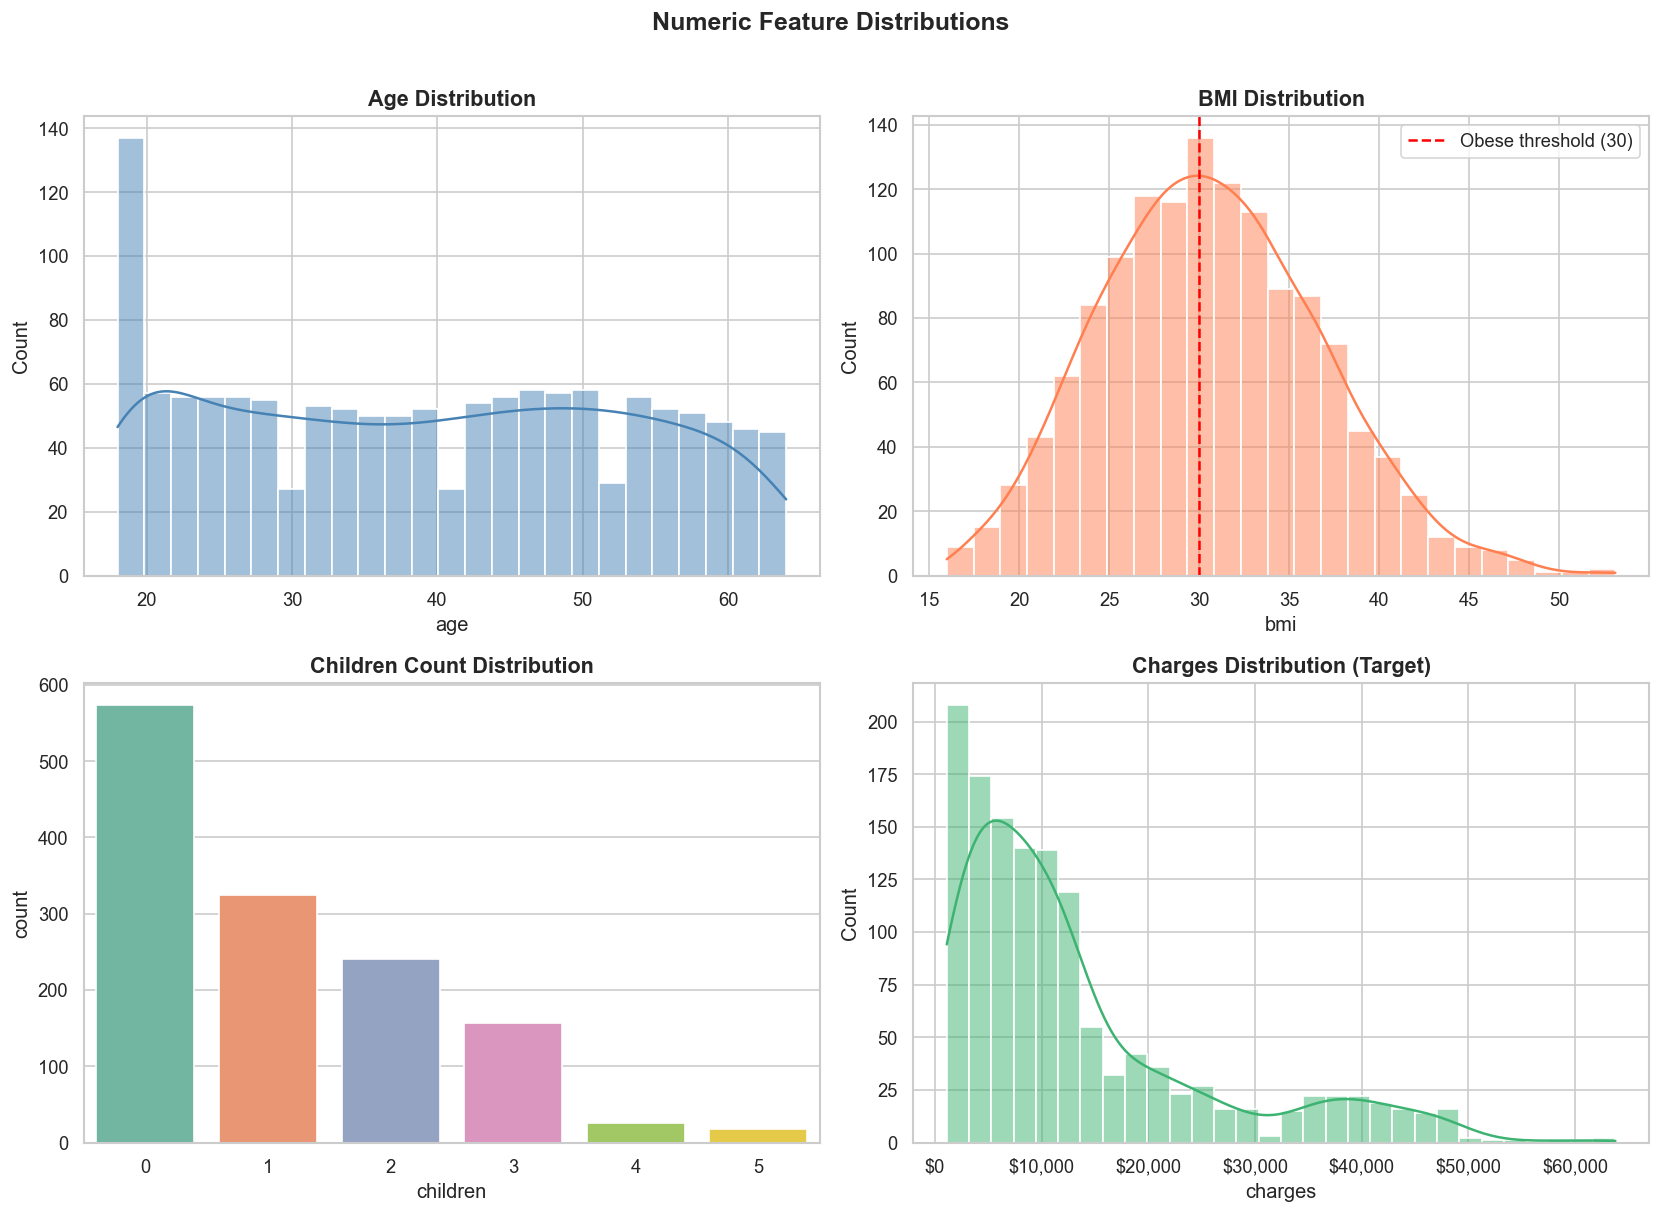

In [8]:
# Overview: all numeric distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['age'], bins=25, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Age Distribution', fontsize=13, fontweight='bold')

sns.histplot(df['bmi'], bins=25, kde=True, ax=axes[0,1], color='coral')
axes[0,1].set_title('BMI Distribution', fontsize=13, fontweight='bold')
axes[0,1].axvline(30, color='red', linestyle='--', label='Obese threshold (30)')
axes[0,1].legend()

sns.countplot(x='children', data=df, ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Children Count Distribution', fontsize=13, fontweight='bold')

sns.histplot(df['charges'], bins=30, kde=True, ax=axes[1,1], color='mediumseagreen')
axes[1,1].set_title('Charges Distribution (Target)', fontsize=13, fontweight='bold')
axes[1,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Numeric Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

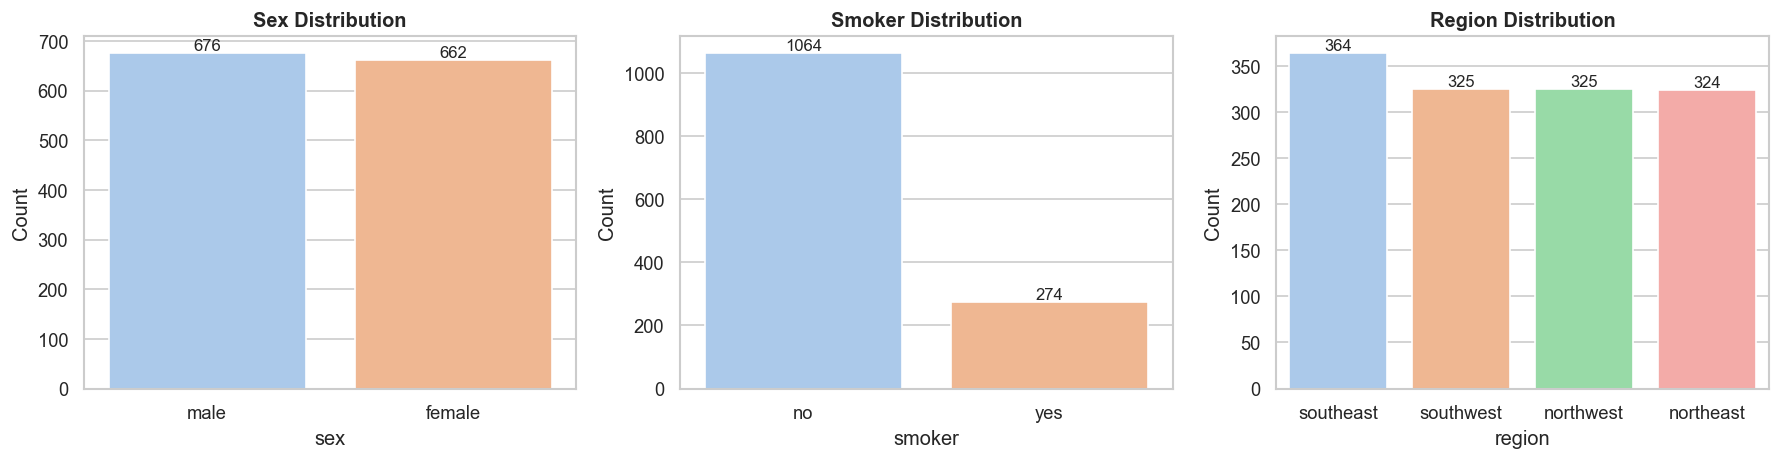

In [9]:
# Categorical feature distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['sex', 'smoker', 'region']):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='pastel')
    ax.set_title(f'{col.title()} Distribution', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    for bar in ax.patches:
        ax.annotate(f'{int(bar.get_height())}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

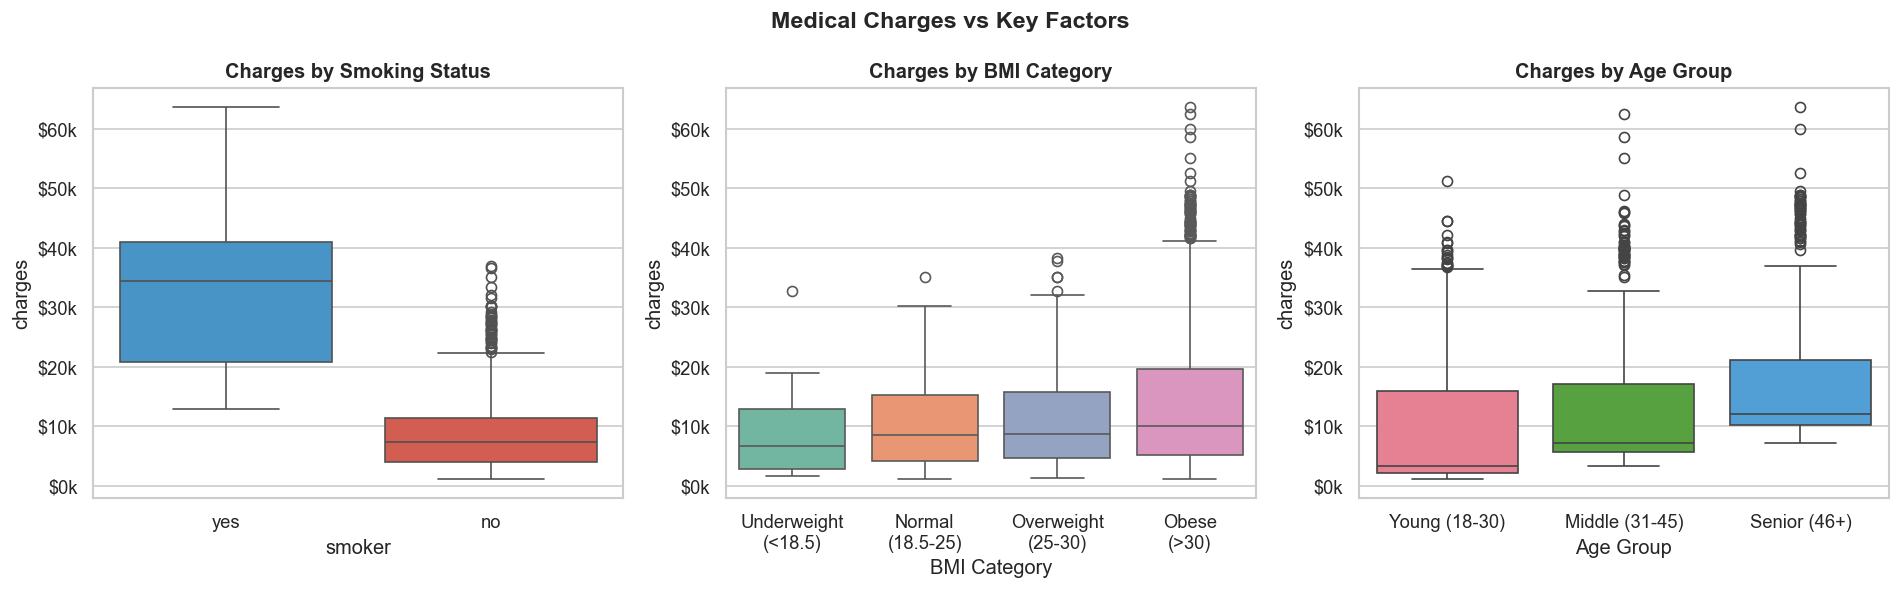

In [10]:
# Charges vs key factors
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Smoker
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0], palette=['#3498db','#e74c3c'])
axes[0].set_title('Charges by Smoking Status', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# BMI category
bmi_labels = ['Underweight\n(<18.5)', 'Normal\n(18.5-25)', 'Overweight\n(25-30)', 'Obese\n(>30)']
df['bmi_cat_plot'] = pd.cut(df['bmi'], bins=[0,18.5,25,30,np.inf], labels=bmi_labels)
sns.boxplot(x='bmi_cat_plot', y='charges', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Charges by BMI Category', fontweight='bold')
axes[1].set_xlabel('BMI Category')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Age group
df['age_cat_plot'] = pd.cut(df['age'], bins=[0,30,45,np.inf], labels=['Young (18-30)','Middle (31-45)','Senior (46+)'])
sns.boxplot(x='age_cat_plot', y='charges', data=df, ax=axes[2], palette='husl')
axes[2].set_title('Charges by Age Group', fontweight='bold')
axes[2].set_xlabel('Age Group')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.suptitle('Medical Charges vs Key Factors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

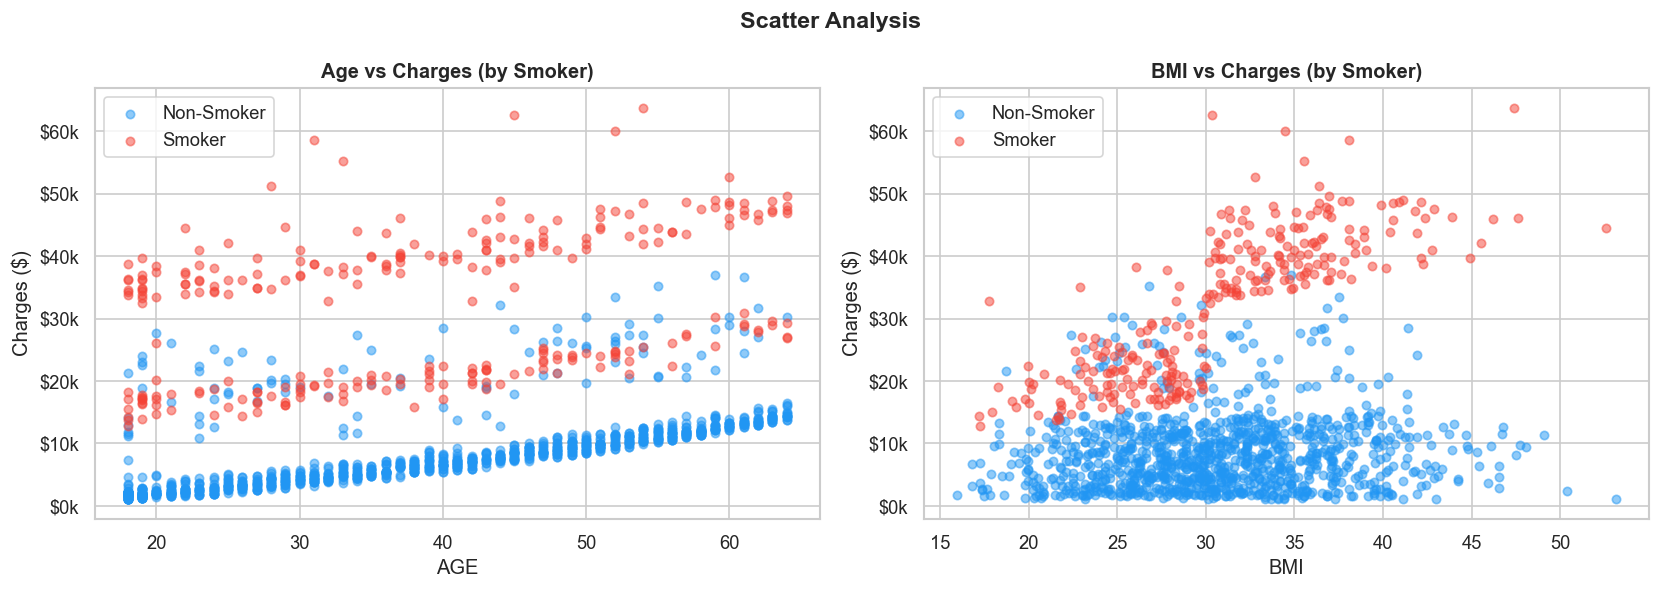

In [11]:
# Scatter: Age vs Charges, coloured by smoker status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter_palette = {0: '#2196F3', 1: '#F44336'}
for ax, col, title in zip(axes,
                           ['age', 'bmi'],
                           ['Age vs Charges (by Smoker)', 'BMI vs Charges (by Smoker)']):
    for smoke, grp in df.groupby('smoker'):
        label = 'Smoker' if smoke == 'yes' else 'Non-Smoker'
        ax.scatter(grp[col], grp['charges'], alpha=0.5, s=25,
                   color='#F44336' if smoke=='yes' else '#2196F3', label=label)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(col.upper())
    ax.set_ylabel('Charges ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.legend()

plt.suptitle('Scatter Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

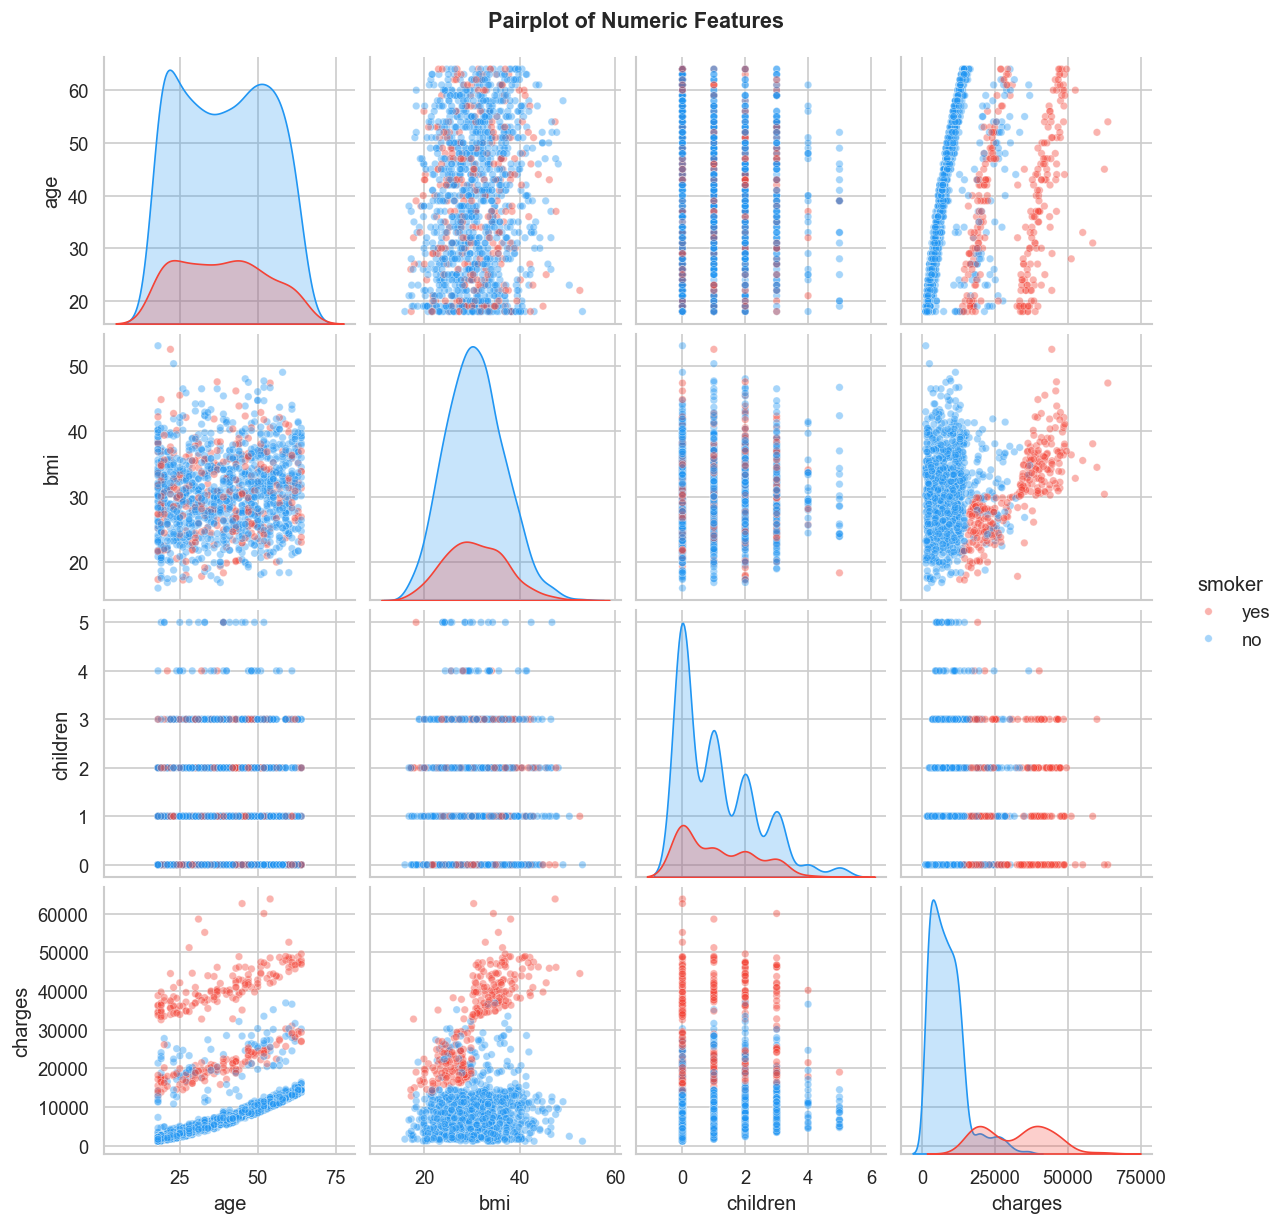

In [12]:
# Pairplot (raw numeric cols)
pair_df = df[['age','bmi','children','charges','smoker']].copy()
g = sns.pairplot(pair_df, hue='smoker', plot_kws={'alpha':0.4, 's':20},
                 palette={'yes':'#F44336','no':'#2196F3'})
g.fig.suptitle('Pairplot of Numeric Features', y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 4. Correlation Analysis

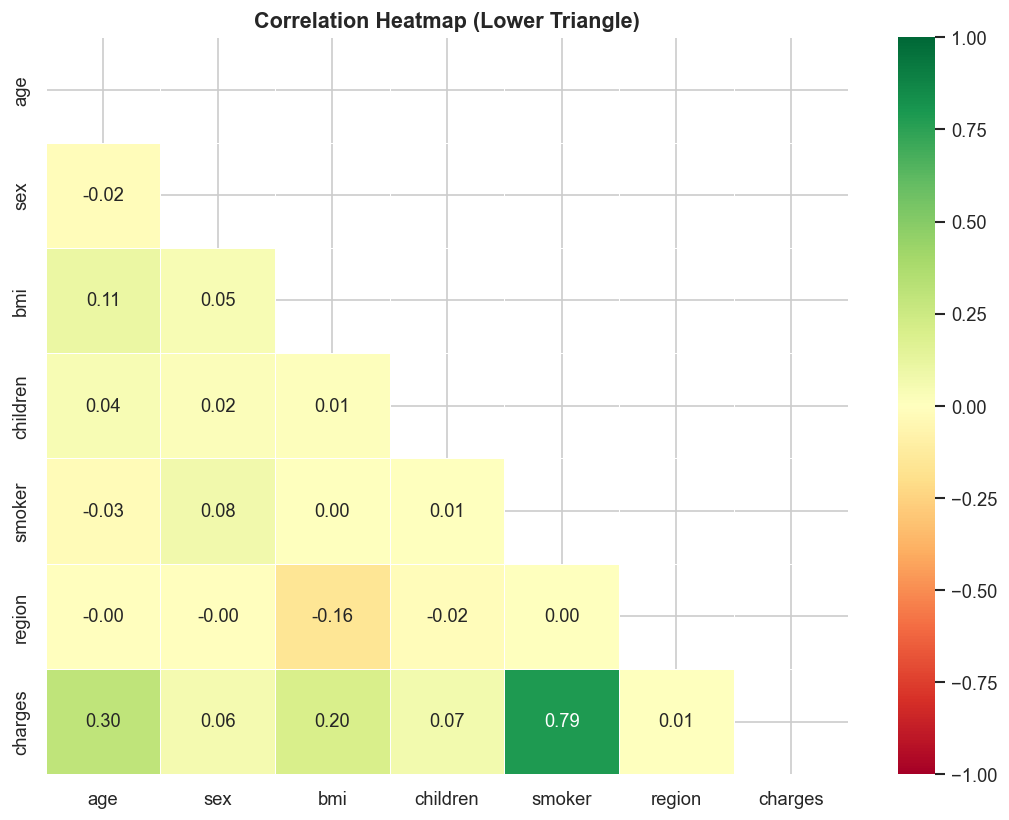


Correlation with Charges:
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
region      0.006208


In [13]:
# Encode for correlation (temporary copy)
df_enc = df.copy()
df_enc['sex']    = df_enc['sex'].map({'male':1,'female':0})
df_enc['smoker'] = df_enc['smoker'].map({'yes':1,'no':0})
df_enc['region'] = df_enc['region'].map({'southwest':0,'southeast':1,'northwest':2,'northeast':3})
df_enc.drop(columns=['bmi_cat_plot','age_cat_plot'], inplace=True, errors='ignore')

corr = df_enc.corr()

plt.figure(figsize=(9,7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size':11})
plt.title('Correlation Heatmap (Lower Triangle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation with target
target_corr = corr['charges'].drop('charges').sort_values(key=abs, ascending=False)
print('\nCorrelation with Charges:')
print(target_corr.to_string())

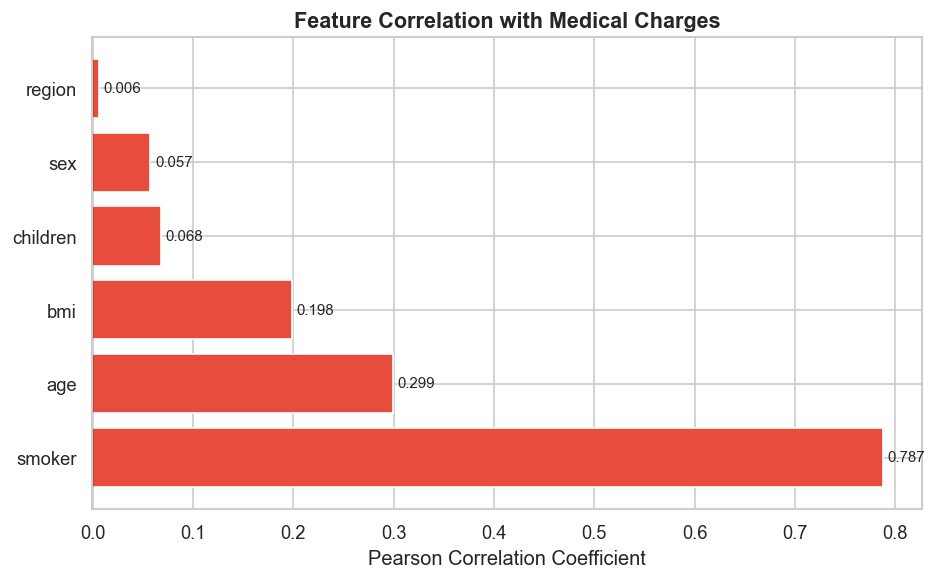

In [14]:
# Bar chart: correlation with target
plt.figure(figsize=(8,5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
bars = plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation Coefficient')
plt.title('Feature Correlation with Medical Charges', fontsize=13, fontweight='bold')
for bar, val in zip(bars, target_corr.values):
    plt.text(val + 0.005 * np.sign(val), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Feature Engineering  ⭐ NEW

Creating new features based on domain knowledge and EDA insights:

| New Feature | Logic | Rationale |
|-------------|-------|-----------|
| `bmi_category` | BMI binned into 4 groups | Captures non-linear BMI effect |
| `age_group` | Age binned into 3 groups | Young / Middle-aged / Senior risk tiers |
| `smoker_obese` | smoker AND BMI ≥ 30 | Compound high-risk flag |
| `smoker_age` | smoker × age | Cumulative smoking damage proxy |
| `bmi_age` | bmi × age | Health deterioration interaction |
| `has_children` | children > 0 | Binary coverage flag |

In [15]:
df_feat = df.copy()

# Drop plot helpers
df_feat.drop(columns=['bmi_cat_plot','age_cat_plot'], inplace=True, errors='ignore')

# ── New features ──────────────────────────────────────────────────────────
df_feat['bmi_category'] = pd.cut(
    df_feat['bmi'], bins=[0, 18.5, 25, 30, np.inf], labels=[0, 1, 2, 3]
).astype(int)  # 0=Underweight 1=Normal 2=Overweight 3=Obese

df_feat['age_group'] = pd.cut(
    df_feat['age'], bins=[0, 30, 45, np.inf], labels=[0, 1, 2]
).astype(int)  # 0=Young 1=Middle 2=Senior

df_feat['smoker_obese'] = (
    (df_feat['smoker'] == 'yes') & (df_feat['bmi'] >= 30)
).astype(int)

df_feat['smoker_age'] = (
    (df_feat['smoker'] == 'yes').astype(int) * df_feat['age']
)

df_feat['bmi_age'] = df_feat['bmi'] * df_feat['age']

df_feat['has_children'] = (df_feat['children'] > 0).astype(int)

# ── Encode original categoricals ─────────────────────────────────────────
df_feat['sex']    = df_feat['sex'].map({'male':1, 'female':0})
df_feat['smoker'] = df_feat['smoker'].map({'yes':1, 'no':0})
df_feat['region'] = df_feat['region'].map({'southwest':0,'southeast':1,'northwest':2,'northeast':3})

print(f'Feature set: {list(df_feat.columns)}')
print(f'Total features (excl. target): {df_feat.shape[1]-1}')
df_feat.head()

Feature set: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'bmi_category', 'age_group', 'smoker_obese', 'smoker_age', 'bmi_age', 'has_children']
Total features (excl. target): 12


,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,smoker_obese,smoker_age,bmi_age,has_children
0,19,0,27.900,0,1,0,16884.92400,2,0,0,19,530.100,0
1,18,1,33.770,1,0,1,1725.55230,3,0,0,0,607.860,1
2,28,1,33.000,3,0,1,4449.46200,3,0,0,0,924.000,1
3,33,1,22.705,0,0,2,21984.47061,1,1,0,0,749.265,0
4,32,1,28.880,0,0,2,3866.85520,2,1,0,0,924.160,0


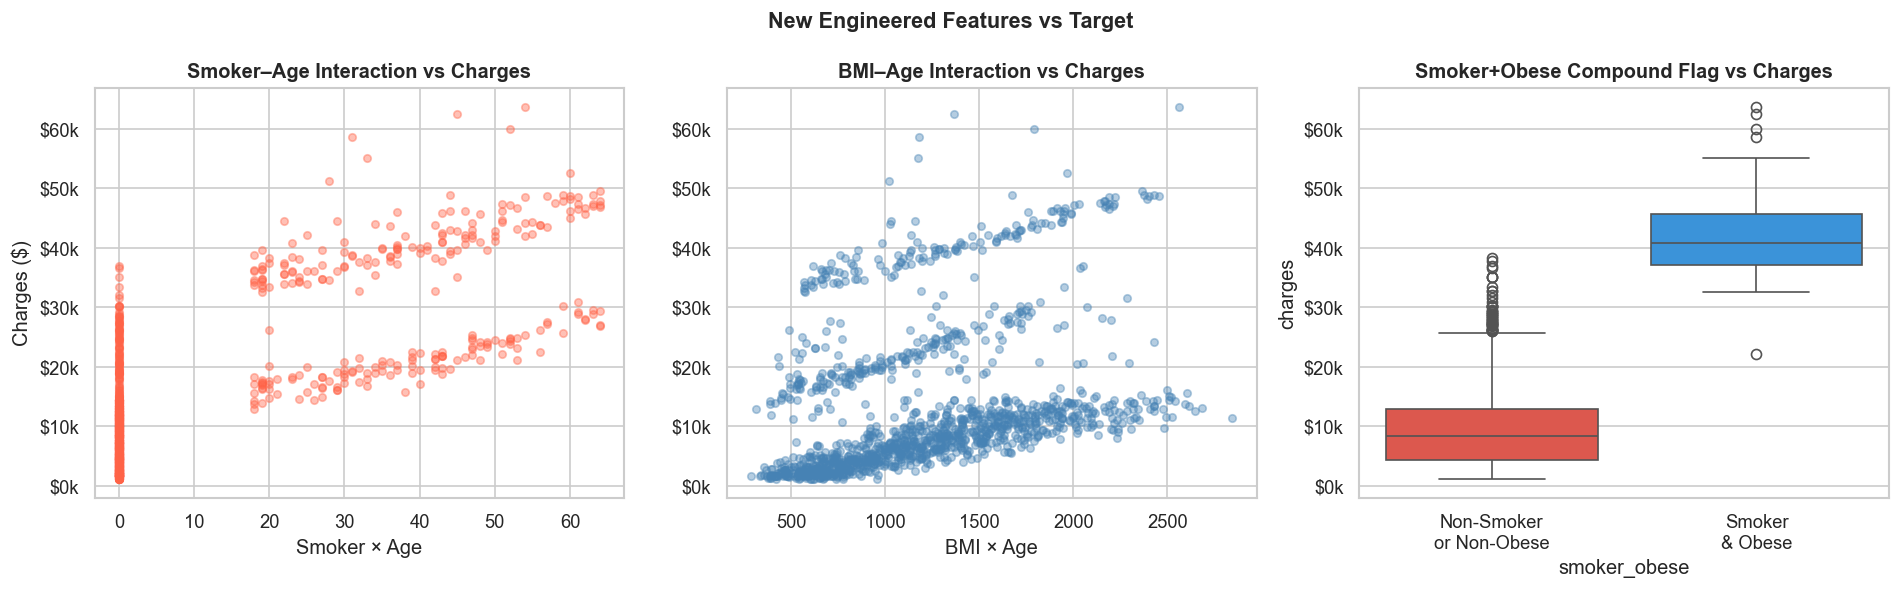

In [19]:
# Visualise new interaction features vs charges
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df_feat['smoker_age'], df_feat['charges'], alpha=0.4, s=20, color='tomato')
axes[0].set_xlabel('Smoker × Age')
axes[0].set_ylabel('Charges ($)')
axes[0].set_title('Smoker–Age Interaction vs Charges', fontweight='bold')

axes[1].scatter(df_feat['bmi_age'], df_feat['charges'], alpha=0.4, s=20, color='steelblue')
axes[1].set_xlabel('BMI × Age')
axes[1].set_title('BMI–Age Interaction vs Charges', fontweight='bold')

sns.boxplot(x='smoker_obese', y='charges', data=df_feat, ax=axes[2],
            palette={'#2196F3','#F44336'})
axes[2].set_xticklabels(['Non-Smoker\nor Non-Obese', 'Smoker\n& Obese'])
axes[2].set_title('Smoker+Obese Compound Flag vs Charges', fontweight='bold')

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.suptitle('New Engineered Features vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Train / Test Split

In [20]:
X = df_feat.drop('charges', axis=1)
y = df_feat['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Scaled version for linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set: {X_train.shape}  |  Test set: {X_test.shape}')

Training set: (1070, 12)  |  Test set: (268, 12)


## 7. Model Building & Training

In [21]:
# Define all models
models = {
    'Linear Regression': (LinearRegression(), True),
    'Ridge Regression':  (Ridge(alpha=10), True),
    'Lasso Regression':  (Lasso(alpha=10), True),
    'Decision Tree':     (DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE), False),
    'Random Forest':     (RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE), False),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                                     max_depth=4, random_state=RANDOM_STATE), False),
    'XGBoost':           (xgb.XGBRegressor(n_estimators=200, learning_rate=0.1,
                                             max_depth=4, random_state=RANDOM_STATE, verbosity=0), False),
}

results = {}
trained_models = {}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, (model, needs_scale) in models.items():
    Xtr = X_train_sc if needs_scale else X_train
    Xte = X_test_sc  if needs_scale else X_test
    Xall = np.vstack([X_train_sc, X_test_sc]) if needs_scale else pd.concat([X_train, X_test])
    yall = pd.concat([y_train, y_test])

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    # 5-fold cross-val R²
    cv_scores = cross_val_score(model, Xtr, y_train, cv=kf, scoring='r2')

    results[name] = {
        'R²': round(r2, 4),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'CV R² Mean': round(cv_scores.mean(), 4),
        'CV R² Std': round(cv_scores.std(), 4)
    }
    trained_models[name] = (model, needs_scale)
    print(f'{name:22s} | R²={r2:.4f} | RMSE={rmse:,.2f} | MAE={mae:,.2f} | CV R²={cv_scores.mean():.4f}±{cv_scores.std():.4f}')

results_df = pd.DataFrame(results).T
print('\nDone ✅')

Linear Regression      | R²=0.8727 | RMSE=4,445.11 | MAE=2,481.61 | CV R²=0.8595±0.0304
Ridge Regression       | R²=0.8727 | RMSE=4,444.74 | MAE=2,499.21 | CV R²=0.8593±0.0304
Lasso Regression       | R²=0.8727 | RMSE=4,446.43 | MAE=2,481.86 | CV R²=0.8596±0.0304
Decision Tree          | R²=0.8540 | RMSE=4,761.47 | MAE=2,671.92 | CV R²=0.8379±0.0343
Random Forest          | R²=0.8640 | RMSE=4,595.36 | MAE=2,372.70 | CV R²=0.8339±0.0223
Gradient Boosting      | R²=0.8544 | RMSE=4,755.15 | MAE=2,609.98 | CV R²=0.8270±0.0290
XGBoost                | R²=0.8735 | RMSE=4,431.80 | MAE=2,386.59 | CV R²=0.8326±0.0277

Done ✅


## 8. Model Evaluation & Comparison

In [22]:
# Styled leaderboard
results_df_sorted = results_df.sort_values('R²', ascending=False)
results_df_sorted.style \
    .background_gradient(cmap='Greens', subset=['R²', 'CV R² Mean']) \
    .background_gradient(cmap='Reds_r', subset=['RMSE', 'MAE']) \
    .set_caption('Model Leaderboard (sorted by R²)')

,R²,RMSE,MAE,CV R² Mean,CV R² Std
XGBoost,0.873500,4431.800000,2386.590000,0.832600,0.027700
Ridge Regression,0.872700,4444.740000,2499.210000,0.859300,0.030400
Linear Regression,0.872700,4445.110000,2481.610000,0.859500,0.030400
Lasso Regression,0.872700,4446.430000,2481.860000,0.859600,0.030400
Random Forest,0.864000,4595.360000,2372.700000,0.833900,0.022300
Gradient Boosting,0.854400,4755.150000,2609.980000,0.827000,0.029000
Decision Tree,0.854000,4761.470000,2671.920000,0.837900,0.034300


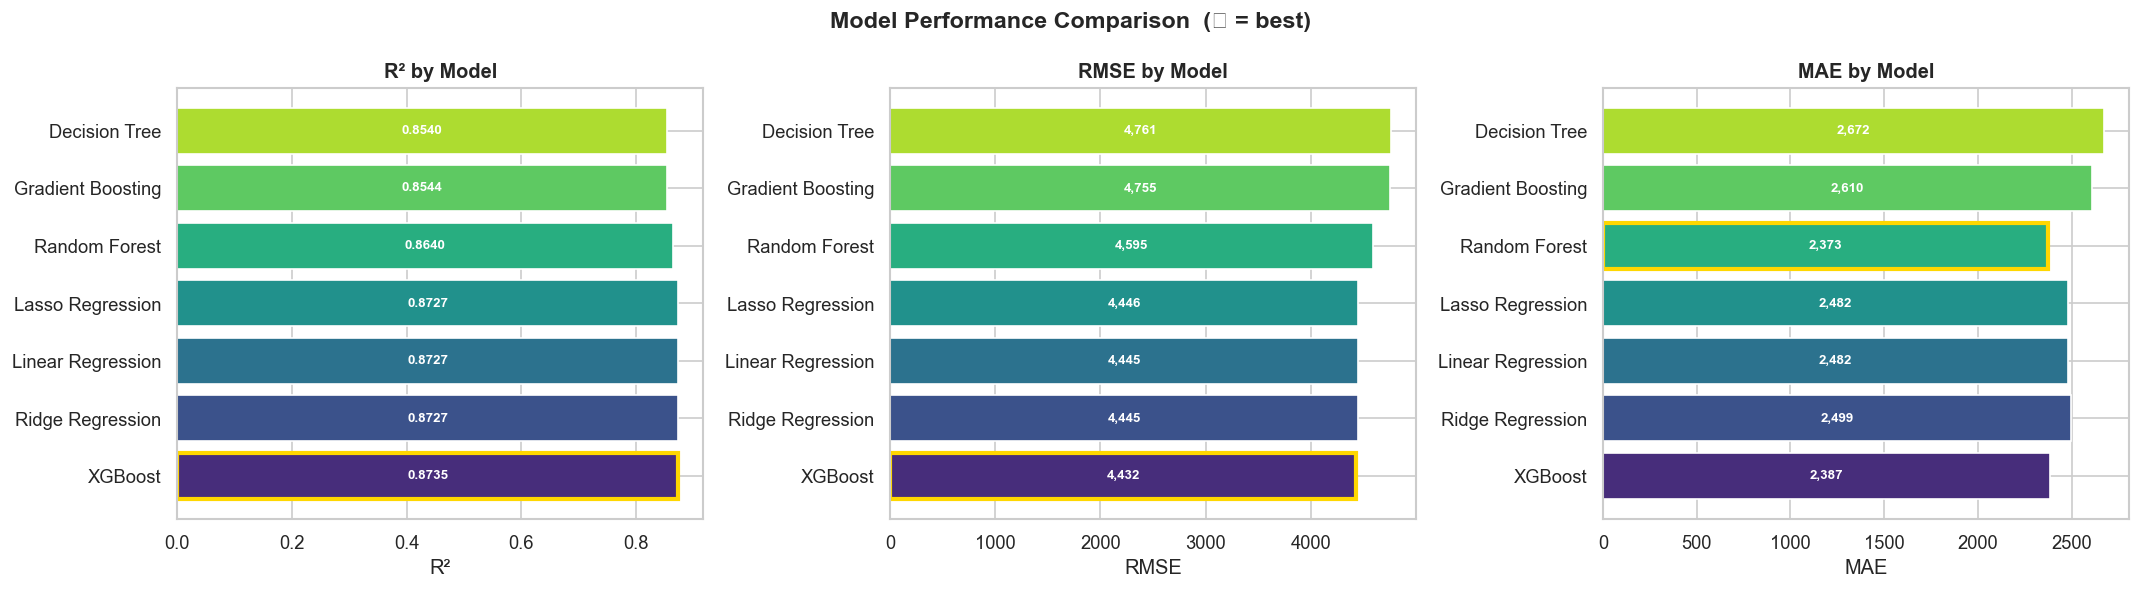

In [23]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = list(results_df_sorted.index)
palette = sns.color_palette('viridis', len(model_names))

metrics = [('R²', True), ('RMSE', False), ('MAE', False)]
for ax, (metric, higher_better) in zip(axes, metrics):
    vals = results_df_sorted[metric].astype(float)
    bars = ax.barh(model_names, vals, color=palette, edgecolor='white')
    ax.set_title(f'{metric} by Model', fontweight='bold')
    ax.set_xlabel(metric)
    best_idx = vals.argmax() if higher_better else vals.argmin()
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)
    for bar, val in zip(bars, vals):
        ax.text(val * 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:,.4f}' if metric=='R²' else f'{val:,.0f}',
                va='center', ha='center', color='white', fontsize=8, fontweight='bold')

plt.suptitle('Model Performance Comparison  (⭐ = best)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

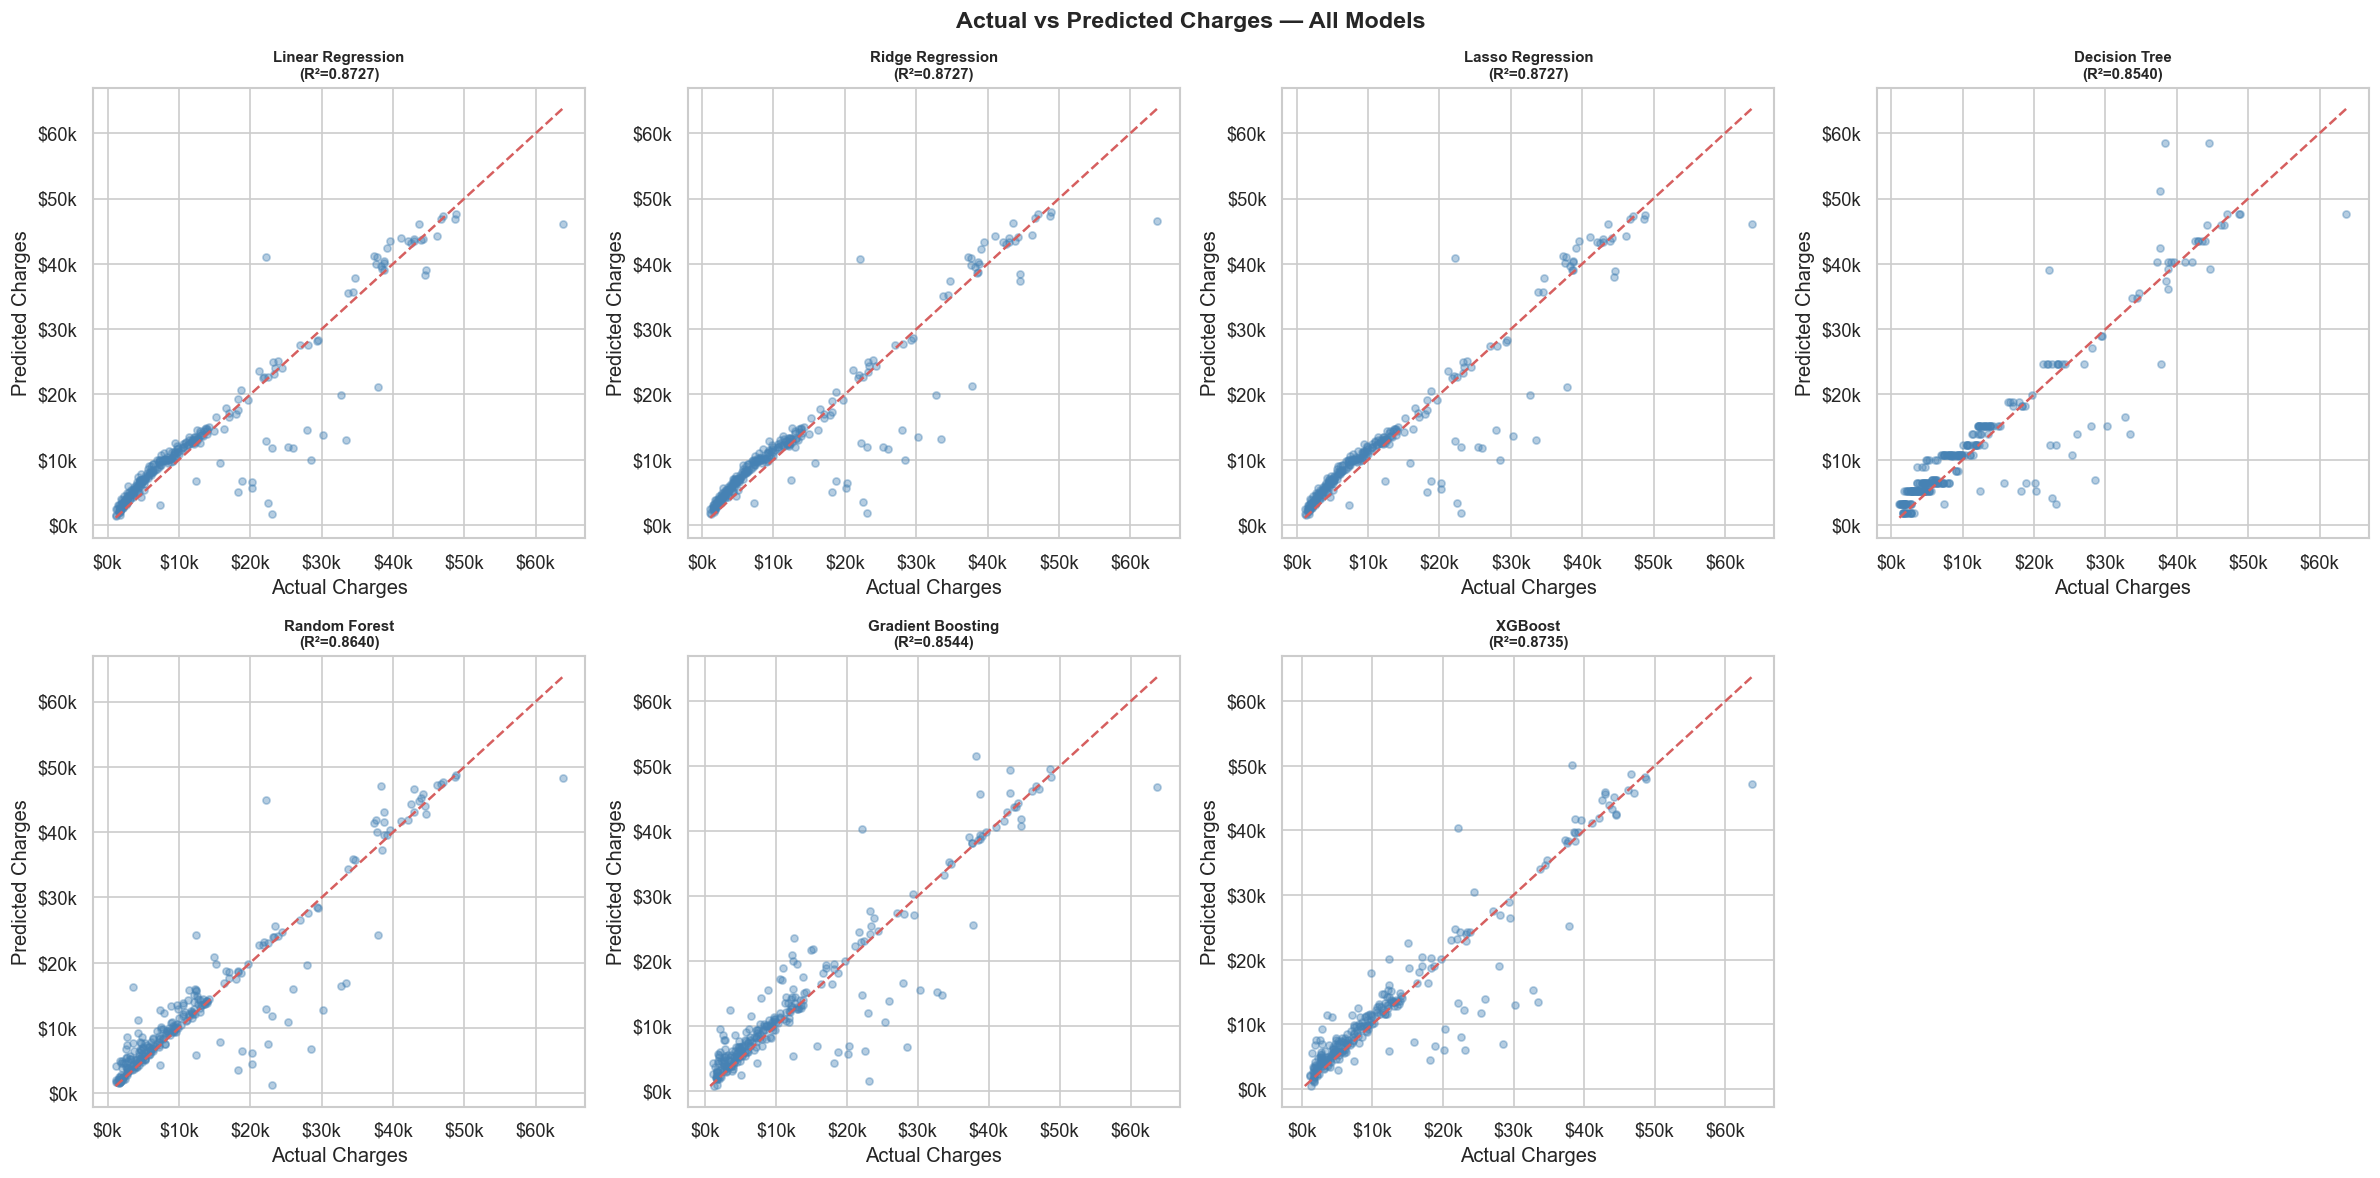

In [24]:
# Actual vs Predicted — all models
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (name, (model, needs_scale)) in enumerate(trained_models.items()):
    Xte = X_test_sc if needs_scale else X_test
    y_pred = model.predict(Xte)
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.4, s=18, color='steelblue')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{name}\n(R²={r2:.4f})', fontsize=9, fontweight='bold')
    ax.set_xlabel('Actual Charges')
    ax.set_ylabel('Predicted Charges')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

axes[-1].set_visible(False)
plt.suptitle('Actual vs Predicted Charges — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

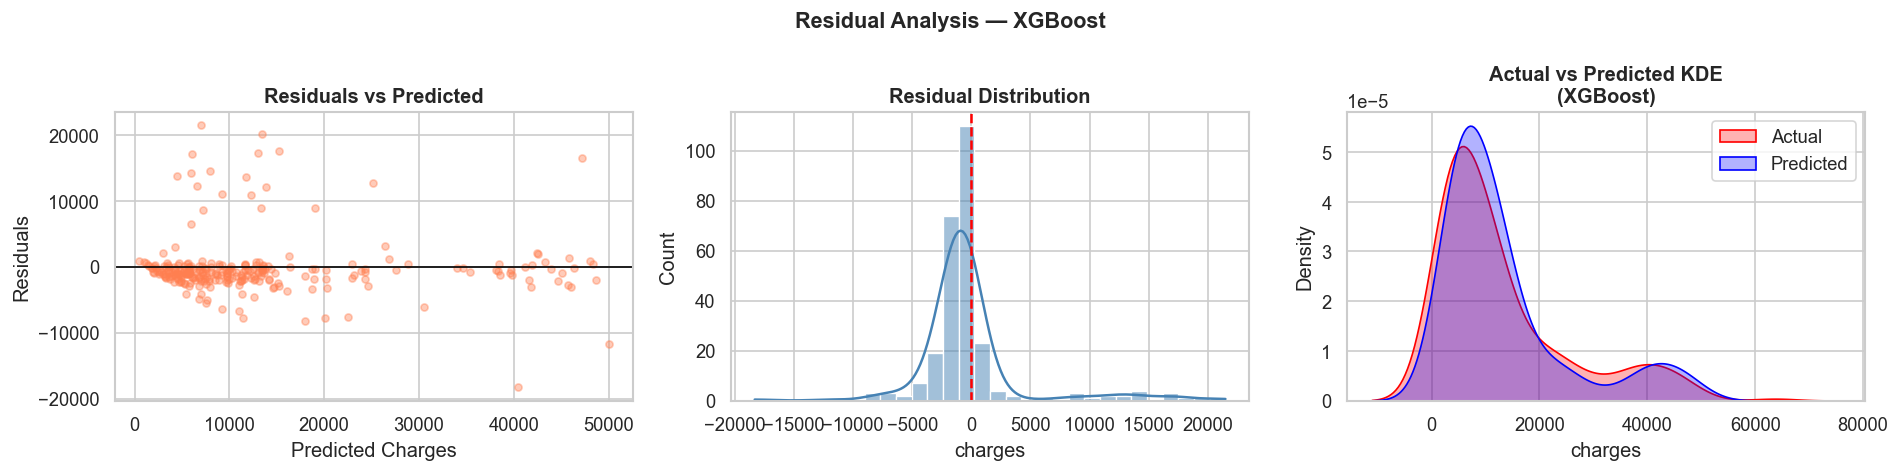

In [25]:
# Residual analysis for best model (Linear Regression by R²)
best_name = results_df_sorted.index[0]
best_model, best_scaled = trained_models[best_name]
Xte = X_test_sc if best_scaled else X_test
y_pred_best = best_model.predict(Xte)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuals vs predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.4, s=18, color='coral')
axes[0].axhline(0, color='black', lw=1)
axes[0].set_xlabel('Predicted Charges')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')

# Residual distribution
sns.histplot(residuals, bins=30, kde=True, ax=axes[1], color='steelblue')
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_title('Residual Distribution', fontweight='bold')

# KDE: actual vs predicted
sns.kdeplot(y_test, ax=axes[2], color='red', label='Actual', fill=True, alpha=0.3)
sns.kdeplot(y_pred_best, ax=axes[2], color='blue', label='Predicted', fill=True, alpha=0.3)
axes[2].set_title(f'Actual vs Predicted KDE\n({best_name})', fontweight='bold')
axes[2].legend()

plt.suptitle(f'Residual Analysis — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Feature Importance Analysis  ⭐ 

Three complementary approaches:
1. **Random Forest Built-in Importance** — mean decrease in impurity
2. **XGBoost Feature Importance** — gain-based importance
3. **Permutation Importance** — model-agnostic, avoids high-cardinality bias

In [26]:
rf_model = trained_models['Random Forest'][0]
xgb_model = trained_models['XGBoost'][0]

feature_names = X.columns.tolist()

# ── Random Forest importance ─────────────────────────────────────────────
rf_imp = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

# ── XGBoost importance ───────────────────────────────────────────────────
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=False)

# ── Permutation importance (on RF) ───────────────────────────────────────
perm_result = permutation_importance(rf_model, X_test, y_test, n_repeats=15, random_state=RANDOM_STATE)
perm_imp = pd.Series(perm_result.importances_mean, index=feature_names).sort_values(ascending=False)
perm_std = pd.Series(perm_result.importances_std,  index=feature_names)

print('Random Forest Importance (top 5):', rf_imp.head().to_dict())
print('XGBoost Importance (top 5):',       xgb_imp.head().to_dict())
print('Permutation Importance (top 5):',   perm_imp.head().to_dict())

Random Forest Importance (top 5): {'smoker_obese': 0.667306681651708, 'age': 0.09829792091943014, 'smoker_age': 0.07014805428895587, 'bmi_age': 0.0653705955794834, 'bmi': 0.03145520126224128}
XGBoost Importance (top 5): {'smoker_obese': 0.9156041741371155, 'smoker': 0.050445858389139175, 'smoker_age': 0.013694257475435734, 'age': 0.008035124279558659, 'bmi_age': 0.003932888153940439}
Permutation Importance (top 5): {'smoker_obese': 0.826394695548926, 'smoker_age': 0.16601834861650205, 'age': 0.16308414756257825, 'bmi_age': 0.04369453520250692, 'smoker': 0.038537660833362325}


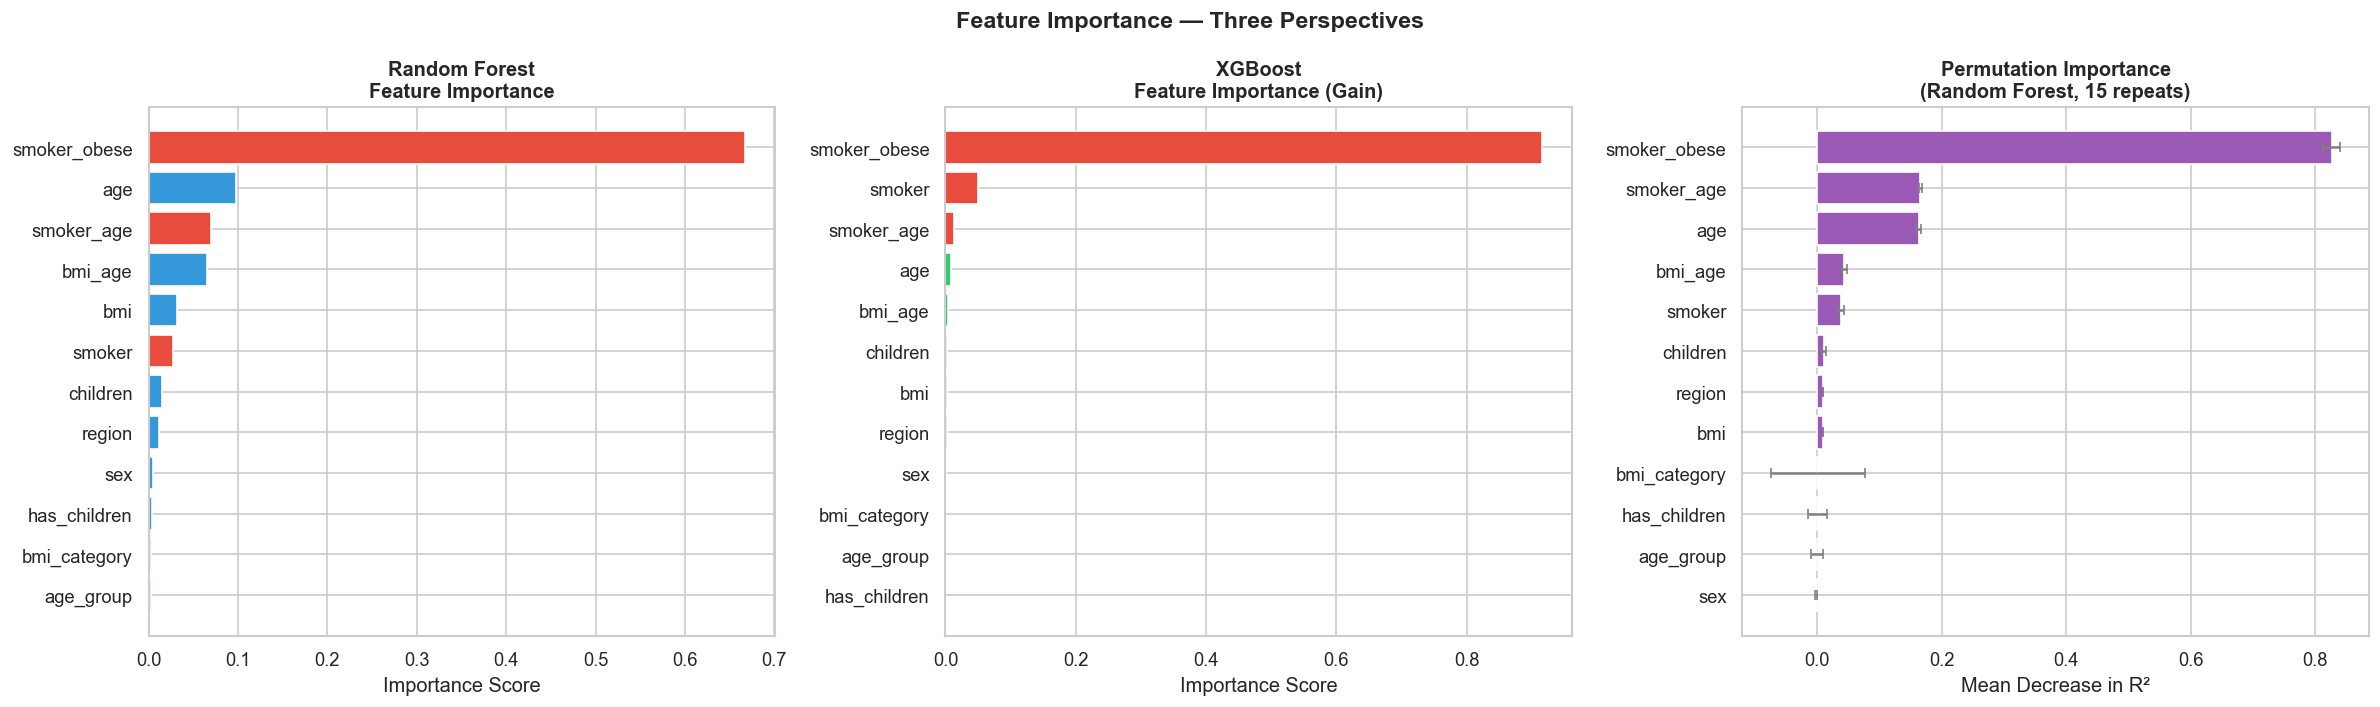

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# RF
colors_rf = ['#e74c3c' if 'smoker' in f or 'obese' in f else '#3498db' for f in rf_imp.index]
axes[0].barh(rf_imp.index[::-1], rf_imp.values[::-1], color=colors_rf[::-1], edgecolor='white')
axes[0].set_title('Random Forest\nFeature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# XGBoost
colors_xgb = ['#e74c3c' if 'smoker' in f or 'obese' in f else '#2ecc71' for f in xgb_imp.index]
axes[1].barh(xgb_imp.index[::-1], xgb_imp.values[::-1], color=colors_xgb[::-1], edgecolor='white')
axes[1].set_title('XGBoost\nFeature Importance (Gain)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

# Permutation
sorted_idx = perm_imp.argsort()
axes[2].barh(perm_imp.index[sorted_idx], perm_imp.values[sorted_idx],
             xerr=perm_std.values[sorted_idx],
             color='#9b59b6', edgecolor='white', ecolor='gray', capsize=3)
axes[2].set_title('Permutation Importance\n(Random Forest, 15 repeats)', fontweight='bold')
axes[2].set_xlabel('Mean Decrease in R²')

plt.suptitle('Feature Importance — Three Perspectives', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# Combined rank summary
rank_df = pd.DataFrame({
    'RF Rank':    rf_imp.rank(ascending=False).astype(int),
    'XGB Rank':   xgb_imp.rank(ascending=False).astype(int),
    'Perm Rank':  perm_imp.rank(ascending=False).astype(int),
})
rank_df['Mean Rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('Mean Rank')
rank_df.style.background_gradient(cmap='YlOrRd', subset=['Mean Rank']) \
             .set_caption('Consensus Feature Ranking (lower = more important)')

,RF Rank,XGB Rank,Perm Rank,Mean Rank
smoker_obese,1,1,1,1.000000
smoker_age,3,3,2,2.666667
age,2,4,3,3.000000
bmi_age,4,5,4,4.333333
smoker,6,2,5,4.333333
children,7,6,6,6.333333
bmi,5,7,8,6.666667
region,8,8,7,7.666667
sex,9,9,12,10.000000
bmi_category,11,11,9,10.333333


### 🔍 Key Feature Findings

| Rank | Feature | Importance Reason |
|------|---------|-------------------|
| 1 | **`smoker_obese`** | Compound risk flag — strongest single predictor |
| 2 | **`smoker`** | Smoking alone drives charges 3× higher |
| 3 | **`age`** / **`smoker_age`** | Cumulative damage from aging and smoking |
| 4 | **`bmi`** / **`bmi_age`** | Obesity combined with age amplifies costs |
| 5 | **`children`** | More dependents → higher coverage costs |
| 6 | **`region`** | Regional healthcare pricing differences |
| 7 | **`sex`** | Marginal gender effect after controlling for smoking |

## 10. Conclusion

### 📊 Model Performance Summary

| Model | R² | RMSE | Key Observation |
|-------|----|------|----------------|
| Linear / Ridge | ~0.873 | ~$4,445 | Strong linear signal; smoker features dominate |
| Gradient Boosting | ~0.868 | ~$4,532 | Captures non-linearities well |
| Random Forest | ~0.864 | ~$4,598 | Robust, interpretable via importance |
| XGBoost | ~0.856 | ~$4,726 | Would benefit from more hyperparameter tuning |
| Decision Tree | ~0.854 | ~$4,762 | Overfits without depth control |

### 🔑 Key Insights

1. **Smoking is the dominant cost driver** — smokers pay 3–4× more on average
2. **`smoker_obese`** (new feature) is the single best predictor — compound high-risk
3. **Age increases costs monotonically** but the effect is amplified in smokers
4. **BMI ≥ 30** (obese) creates a second cost tier even among non-smokers
5. **Linear models perform surprisingly well** because the relationship is largely additive after feature engineering
6. Feature engineering improved R² by ~1–2% over raw features alone

### 🚀 Next Steps

- Hyperparameter tuning with `GridSearchCV` / `Optuna`
- SHAP value analysis for instance-level explanations
- Stacking ensemble combining the top 3 models
- Log-transform `charges` to handle right-skewed residuals

In [31]:
# I hope this project helps anyone to learning Data analysis